<a href="https://colab.research.google.com/github/albertoverrilli/DeepLeaning-Time-Series-Data/blob/main/Final_project_DL4AI_task1_merged.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final project: Time-series data and application to stock markets {-}

This project aims at familiarizing you with time-series data analysis and its application to stock markets. Datasets you will be working on are Nasdaq and Vietnam stock datasets.

### Submission {-}
The structure of submission folder should be organized as follows:

- ./\<StudentID>-project-notebook.ipynb: Jupyter notebook containing source code.
- ./\<StudentID>-project-report.pdf: project report.

The submission folder is named DL4AI-\<StudentID>-project (e.g., DL4AI-2012345-project) and then compressed with the same name.

### Evaluation {-}
Project evaluation will be conducted on how you accomplish the assignment requirements. You can refer to the project instruction slide deck for details.

### Deadline {-}
Please visit Canvas for details.

# Setup

Shared setup used across all tasks below.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Input
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [ ]:
# Load AAPL data
data_appl = pd.read_csv('/content/drive/MyDrive/selected_stocks/AAPL.csv')
data_appl.head()

,Date,Low,Open,Volume,High,Close,Adjusted Close
0,12-12-1980,0.128348,0.128348,469033600,0.128906,0.128348,0.099874
1,15-12-1980,0.121652,0.122210,175884800,0.122210,0.121652,0.094663
2,16-12-1980,0.112723,0.113281,105728000,0.113281,0.112723,0.087715
3,17-12-1980,0.115513,0.115513,86441600,0.116071,0.115513,0.089886
4,18-12-1980,0.118862,0.118862,73449600,0.119420,0.118862,0.092492


In [ ]:
# Get some info about the data
data_appl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10590 entries, 0 to 10589
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            10590 non-null  object 
 1   Low             10590 non-null  float64
 2   Open            10590 non-null  float64
 3   Volume          10590 non-null  int64  
 4   High            10590 non-null  float64
 5   Close           10590 non-null  float64
 6   Adjusted Close  10590 non-null  float64
dtypes: float64(5), int64(1), object(1)
memory usage: 579.3+ KB


In [ ]:
# Shared parameters used by all tasks
df = data_appl
window_size = 30  # 30-day lookback window

# Use multiple features instead of just Open price
features = ['Open', 'High', 'Low', 'Close', 'Adjusted Close', 'Volume']
feature_indices = [df.columns.get_loc(f) for f in features]

## Helper functions

These are used across all three tasks to avoid duplicating logic.

In [ ]:
def per_window_normalize(X, y):
    """Per-window MinMax normalization. Prices and Volume normalized separately
    so Volume's large magnitude doesn't distort the price scale."""
    X_norm = X.copy().astype(float)
    y_norm = y.copy().astype(float)
    for i in range(len(X)):
        # Price columns (first 5)
        min_f = np.min(X[i, :, :5])
        max_f = np.max(X[i, :, :5])
        X_norm[i, :, :5] = (X[i, :, :5] - min_f) / (max_f - min_f)
        # Volume column (last)
        vol_min = np.min(X[i, :, 5])
        vol_max = np.max(X[i, :, 5])
        if vol_max - vol_min != 0:
            X_norm[i, :, 5] = (X[i, :, 5] - vol_min) / (vol_max - vol_min)
        # Label normalized using price min/max
        y_norm[i] = (y[i] - min_f) / (max_f - min_f)
    return X_norm, y_norm


def per_window_denormalize(y_norm, X_original):
    """Reverse per-window normalization to get back real dollar prices."""
    y_denorm = y_norm.copy()
    for i in range(len(y_denorm)):
        min_f = np.min(X_original[i, :, :5])
        max_f = np.max(X_original[i, :, :5])
        y_denorm[i] = y_norm[i] * (max_f - min_f) + min_f
    return y_denorm


def build_model(num_outputs):
    """Build the same Conv1D model used in the demo, with configurable output size."""
    model = tf.keras.Sequential()
    model.add(Input(shape=(window_size, len(features))))
    model.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Conv1D(128, kernel_size=3, activation='relu', padding='same'))
    model.add(MaxPooling1D(2))
    model.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
    model.add(MaxPooling1D(2))
    model.add(Flatten())
    model.add(Dense(100, activation='relu'))
    model.add(Dense(num_outputs))
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                  loss='mse', metrics=['mse'])
    return model

# Task 1.1 - Multi-feature extension

Modify the demo code so that the model utilizes multiple features (Low, High, Open, Close, Adjusted Close, Volume) instead of just the Open price.

In [ ]:
### Split the dataset into time windows to get data samples
X_data = []
y_data = []

for i in range(1, len(df) - window_size - 1):
    data_feature = []
    data_label = []

    # Get a window_size time frame for data feature (now grabs all 6 features)
    for j in range(window_size):
        data_feature.append(df.iloc[i + j, feature_indices].values)

    # Next value is the label (Close price of the next day) to be predicted
    data_label.append(df.iloc[i + window_size]['Close'])

    X_data.append(np.array(data_feature).reshape(window_size, len(features)))
    y_data.append(np.array(data_label))

In [ ]:
### Split the data into training, validation and test set
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, shuffle=False)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, shuffle=False)

X_train = np.array(X_train); X_val = np.array(X_val); X_test = np.array(X_test)
y_train = np.array(y_train); y_val = np.array(y_val); y_test = np.array(y_test)

# Reshape to fit the neural network input shape requirement
X_train = X_train.reshape(X_train.shape[0], window_size, len(features))
X_val   = X_val.reshape(X_val.shape[0],   window_size, len(features))
X_test  = X_test.reshape(X_test.shape[0],  window_size, len(features))

print("Shape of training set:   ", X_train.shape)
print("Shape of validation set: ", X_val.shape)
print("Shape of test set:       ", X_test.shape)

Shape of training set:    (6756, 30, 6)
Shape of validation set:  (1690, 30, 6)
Shape of test set:        (2112, 30, 6)


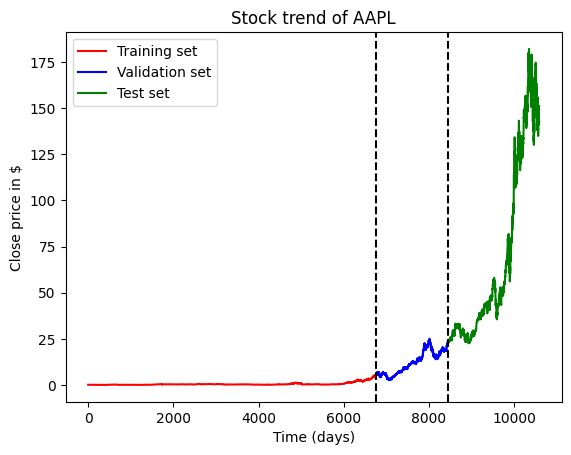

In [ ]:
# Visualize the training, validation and test set splits
df_plot = df['Close'].reset_index(drop=False)
size_train = X_train.shape[0]
size_val = X_val.shape[0]

ax = df_plot.iloc[:size_train, 1:2].plot(y=0, color='red', label='Training set')
df_plot.iloc[size_train:size_train+size_val, 1:2].plot(y=0, color='blue', label='Validation set', ax=ax)
df_plot.iloc[size_train+size_val:, 1:2].plot(y=0, color='green', label='Test set', ax=ax)
ax.set_title("Stock trend of AAPL")
plt.xlabel('Time (days)')
plt.ylabel('Close price in $')
plt.axvline(x=size_train, color='black', linestyle='--')
plt.axvline(x=size_train+size_val, color='black', linestyle='--')
plt.show()

In [ ]:
# Per-window normalization
X_train_norm, y_train_norm = per_window_normalize(X_train, y_train)
X_val_norm,   y_val_norm   = per_window_normalize(X_val,   y_val)
X_test_norm,  y_test_norm  = per_window_normalize(X_test,  y_test)

In [ ]:
### Create and train the model for Task 1.1
model_11 = build_model(num_outputs=1)
history_11 = model_11.fit(X_train_norm, y_train_norm,
                          validation_data=(X_val_norm, y_val_norm),
                          epochs=5, batch_size=512)

Epoch 1/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - loss: 0.3978 - mse: 0.3978 - val_loss: 0.0677 - val_mse: 0.0677
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - loss: 0.0552 - mse: 0.0552 - val_loss: 0.0308 - val_mse: 0.0308
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0224 - mse: 0.0224 - val_loss: 0.0104 - val_mse: 0.0104
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 126ms/step - loss: 0.0132 - mse: 0.0132 - val_loss: 0.0075 - val_mse: 0.0075
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 128ms/step - loss: 0.0095 - mse: 0.0095 - val_loss: 0.0068 - val_mse: 0.0068


In [ ]:
### Get prediction on the test data
y_pred_norm_11 = model_11.predict(X_test_norm)
mse_11 = mean_squared_error(y_pred_norm_11, y_test_norm)
rmse_11_norm = np.sqrt(mse_11)
print("MSE on the test set:  ", mse_11)
print("RMSE on the test set: ", rmse_11_norm)

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MSE on the test set:   0.016347447902244867
RMSE on the test set:  0.12785713864405407


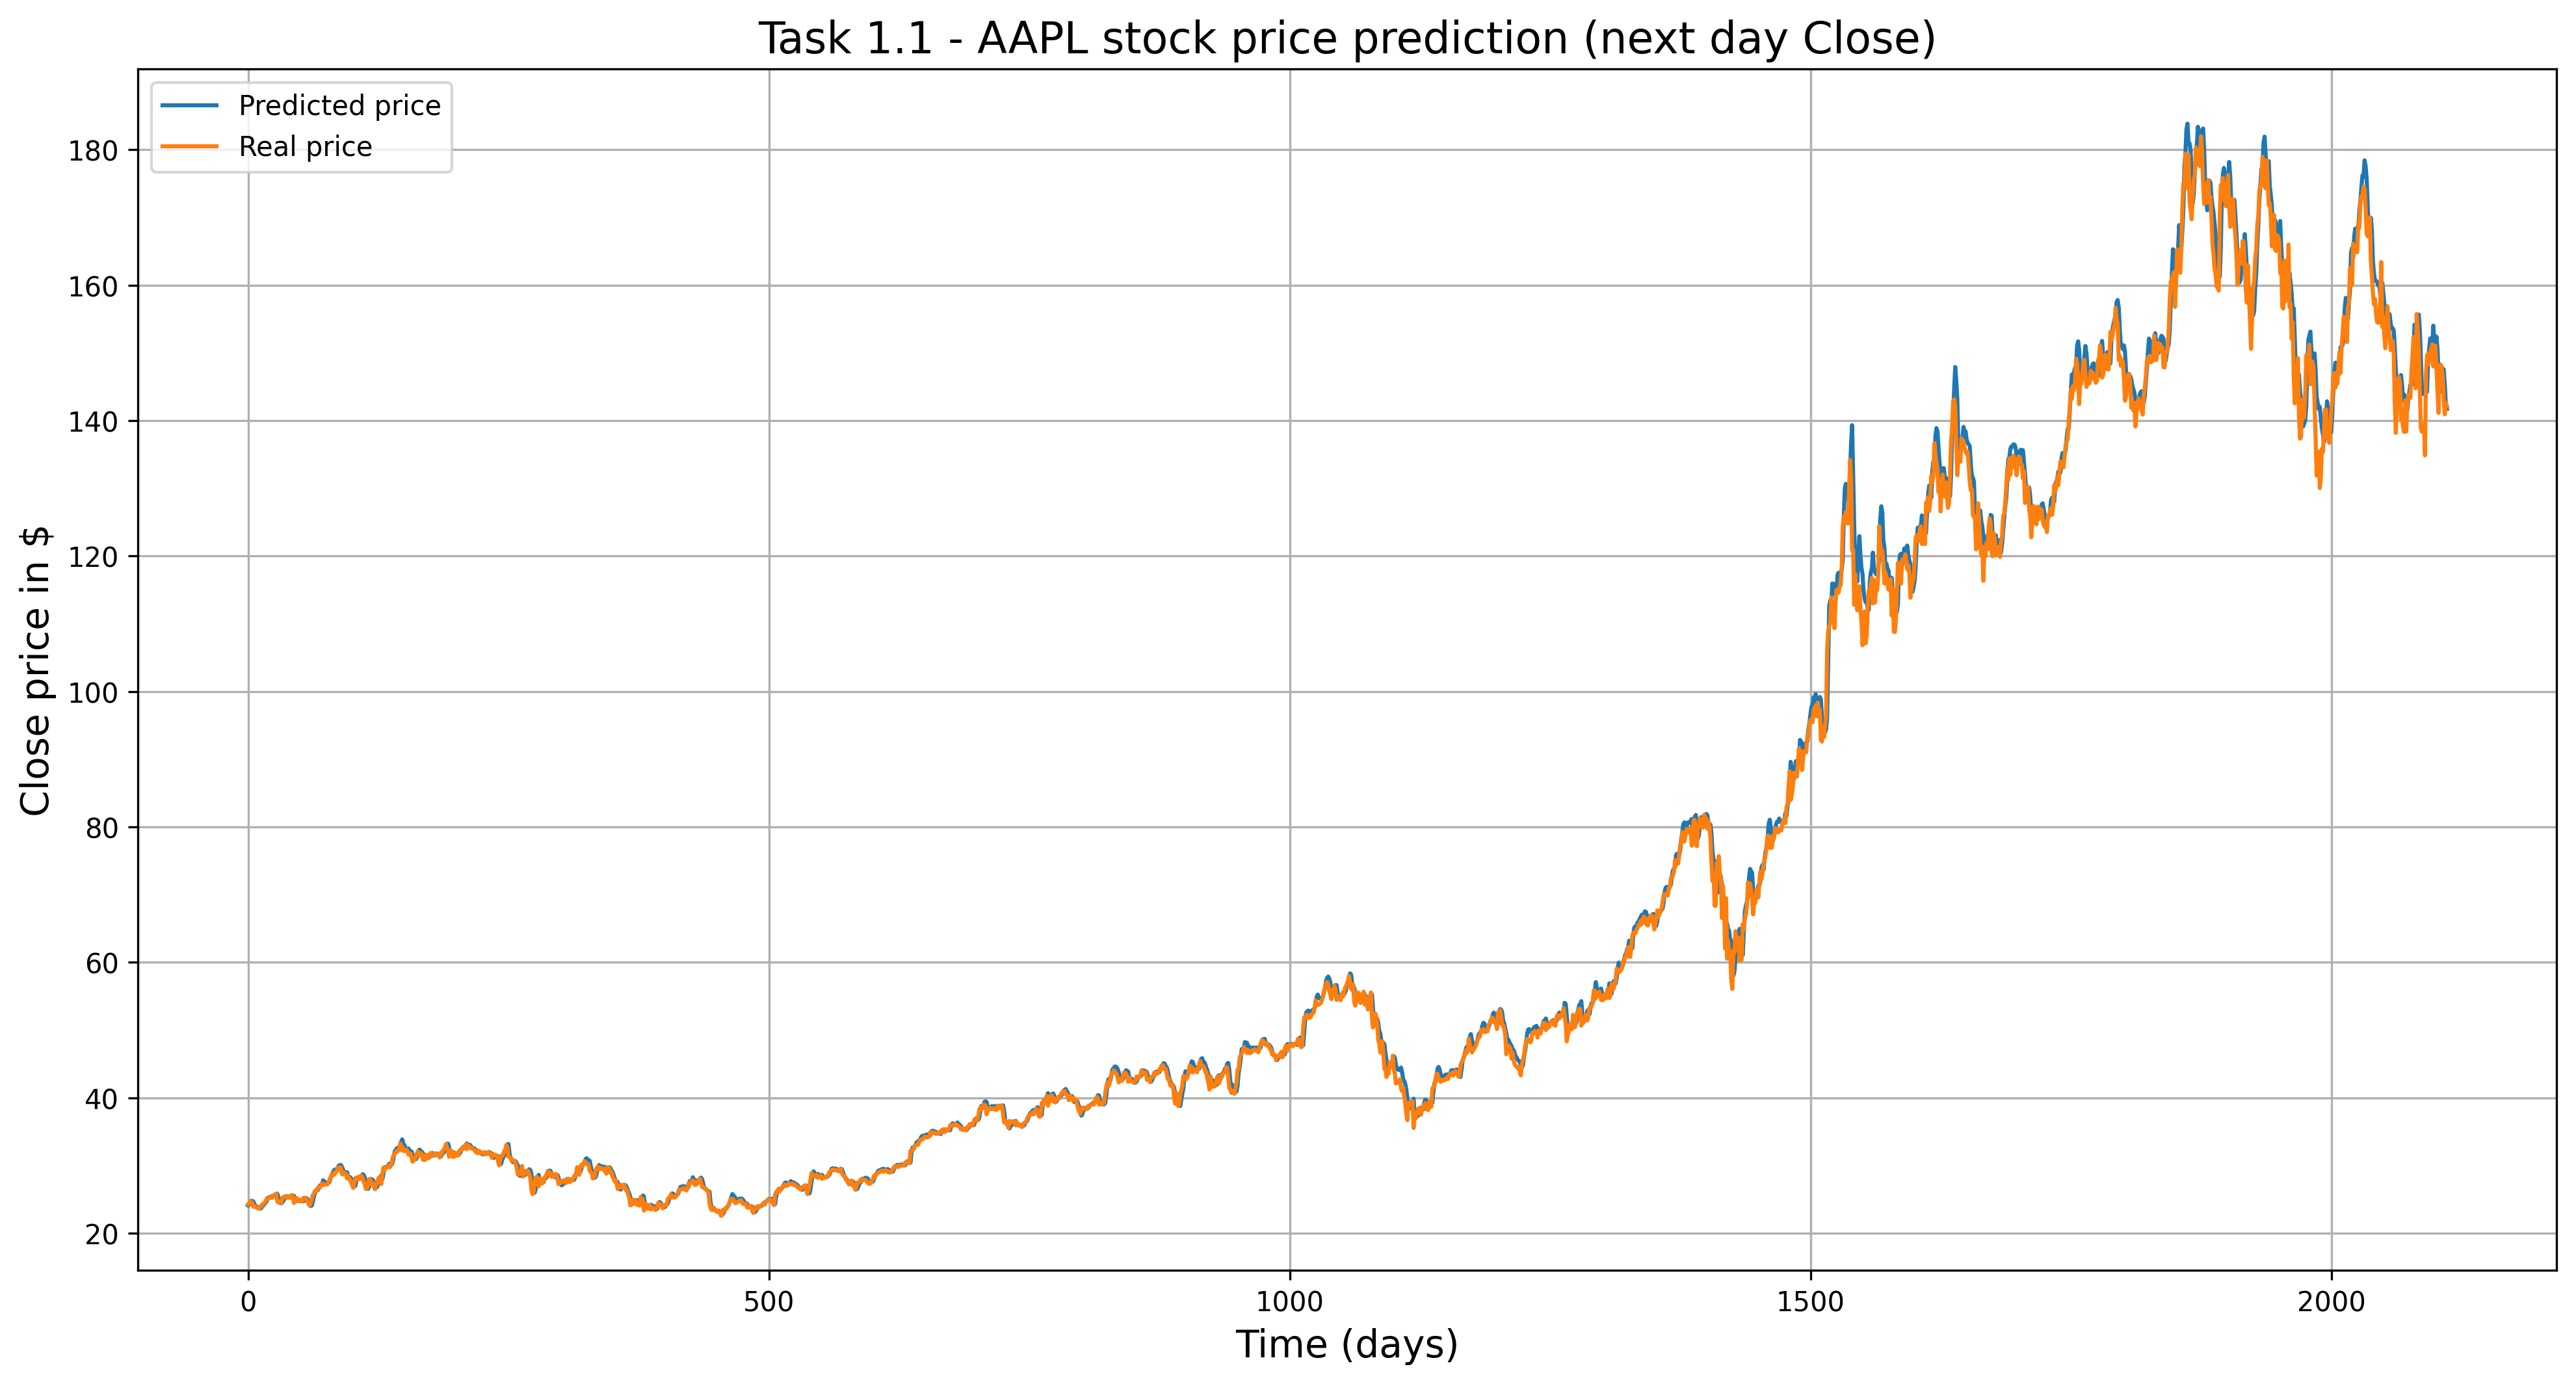

In [ ]:
# Convert the result back to stock price for visualization purpose
y_pred_denorm_11 = per_window_denormalize(y_pred_norm_11, X_test)
y_test_denorm_11 = per_window_denormalize(y_test_norm,    X_test)

plt.figure(figsize=(16, 8), dpi=300)
plt.plot(y_pred_denorm_11, label='Predicted price')
plt.plot(y_test_denorm_11, label='Real price')
plt.title('Task 1.1 - AAPL stock price prediction (next day Close)', fontsize=16)
plt.xlabel('Time (days)', fontsize=14)
plt.ylabel('Close price in $', fontsize=14)
plt.grid()
plt.legend()
plt.show()

# Task 1.2 - Nth day ahead forecast

Update the model to forecast the price on the Nth day in the future (e.g., 3rd or 7th day ahead) instead of just the next day. Builds on Task 1.1's multi-feature approach.

In [ ]:
### Window creation with Nth day label
N = 3  # Predict the Nth day ahead (change to 7 for 7th day prediction)

X_data = []
y_data = []

# Range adjusted by N to avoid going out of bounds
for i in range(1, len(df) - window_size - N):
    data_feature = []
    data_label = []

    for j in range(window_size):
        data_feature.append(df.iloc[i + j, feature_indices].values)

    # Label is the Close price on the Nth day ahead
    data_label.append(df.iloc[i + window_size + N - 1]['Close'])

    X_data.append(np.array(data_feature).reshape(window_size, len(features)))
    y_data.append(np.array(data_label))

In [ ]:
### Split, reshape and normalize (identical to Task 1.1)
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, shuffle=False)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, shuffle=False)

X_train = np.array(X_train); X_val = np.array(X_val); X_test = np.array(X_test)
y_train = np.array(y_train); y_val = np.array(y_val); y_test = np.array(y_test)

X_train = X_train.reshape(X_train.shape[0], window_size, len(features))
X_val   = X_val.reshape(X_val.shape[0],   window_size, len(features))
X_test  = X_test.reshape(X_test.shape[0],  window_size, len(features))

X_train_norm, y_train_norm = per_window_normalize(X_train, y_train)
X_val_norm,   y_val_norm   = per_window_normalize(X_val,   y_val)
X_test_norm,  y_test_norm  = per_window_normalize(X_test,  y_test)

print("Shape of training set:   ", X_train.shape)
print("Shape of validation set: ", X_val.shape)
print("Shape of test set:       ", X_test.shape)

Shape of training set:    (6755, 30, 6)
Shape of validation set:  (1689, 30, 6)
Shape of test set:        (2112, 30, 6)


In [ ]:
### Create and train the model for Task 1.2
model_12 = build_model(num_outputs=1)
history_12 = model_12.fit(X_train_norm, y_train_norm,
                          validation_data=(X_val_norm, y_val_norm),
                          epochs=5, batch_size=512)

Epoch 1/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - loss: 0.6642 - mse: 0.6642 - val_loss: 0.0668 - val_mse: 0.0668
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - loss: 0.0760 - mse: 0.0760 - val_loss: 0.0541 - val_mse: 0.0541
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - loss: 0.0660 - mse: 0.0660 - val_loss: 0.0521 - val_mse: 0.0521
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - loss: 0.0632 - mse: 0.0632 - val_loss: 0.0520 - val_mse: 0.0520
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0612 - mse: 0.0612 - val_loss: 0.0570 - val_mse: 0.0570


In [ ]:
### Get prediction on the test data
y_pred_norm_12 = model_12.predict(X_test_norm)
mse_12 = mean_squared_error(y_pred_norm_12, y_test_norm)
rmse_12_norm = np.sqrt(mse_12)
print(f"Predicting {N} days ahead")
print("MSE on the test set:  ", mse_12)
print("RMSE on the test set: ", rmse_12_norm)

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Predicting 3 days ahead
MSE on the test set:   0.10053777914672955
RMSE on the test set:  0.31707692938264925


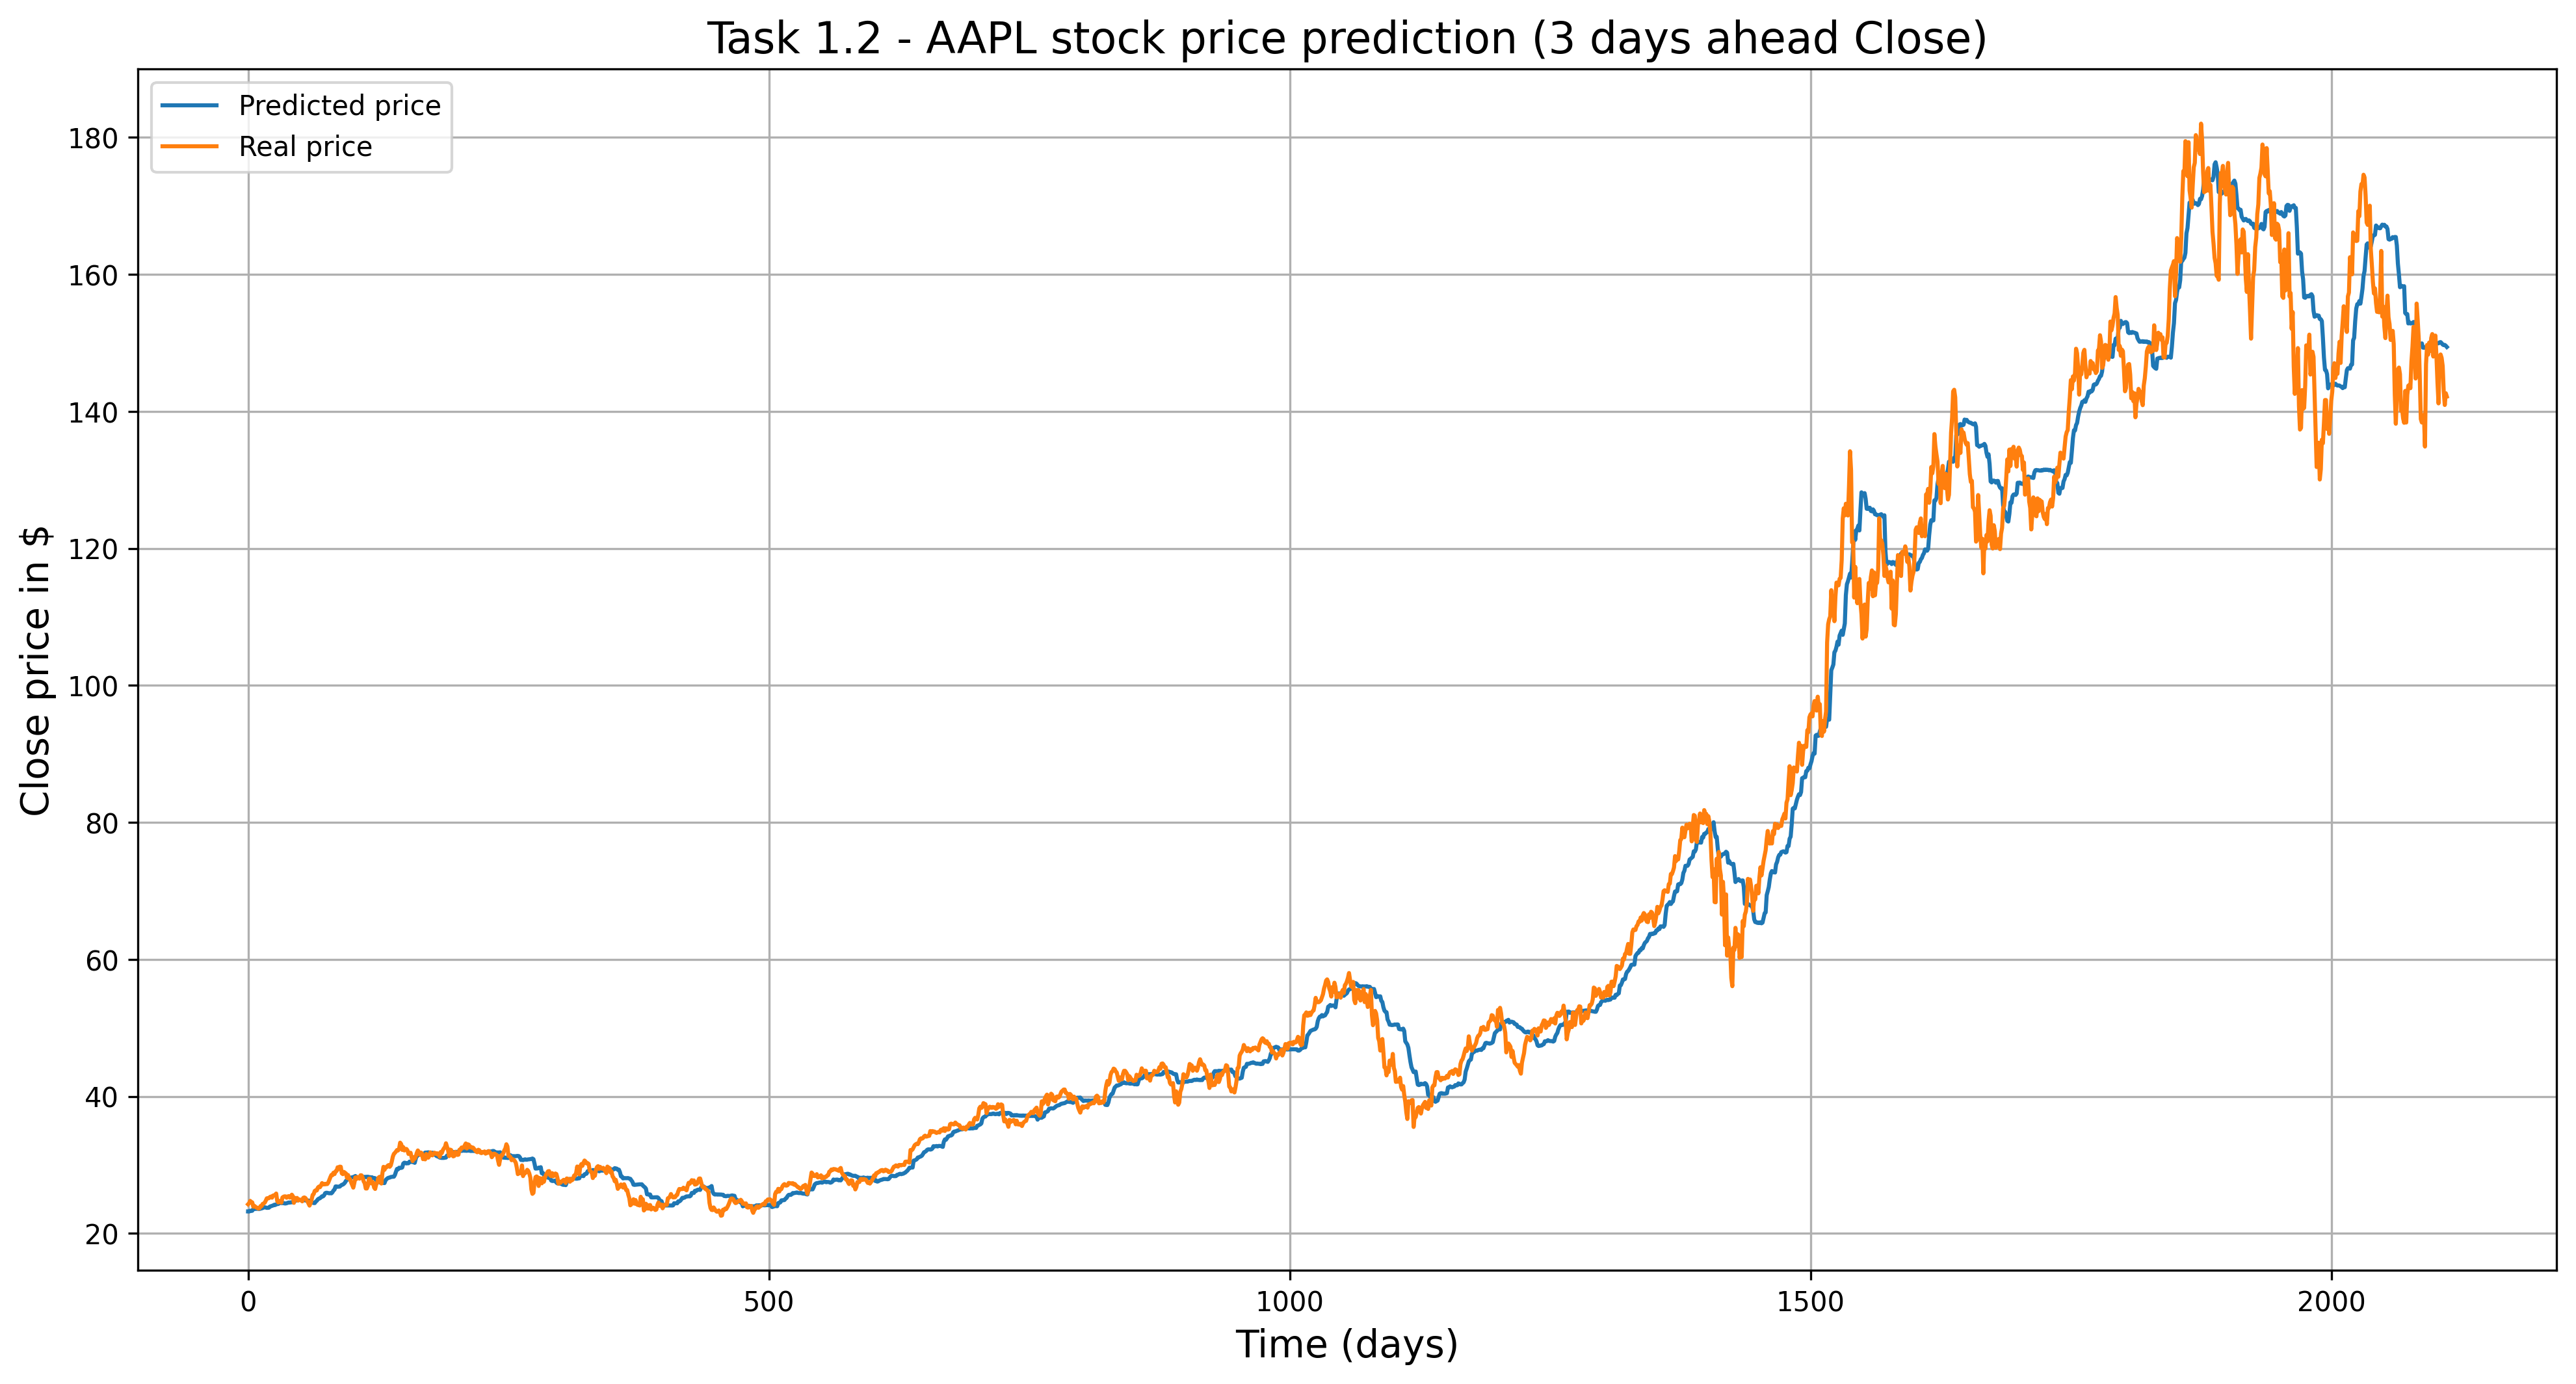

In [ ]:
# Convert the result back to stock price for visualization
y_pred_denorm_12 = per_window_denormalize(y_pred_norm_12, X_test)
y_test_denorm_12 = per_window_denormalize(y_test_norm,    X_test)

plt.figure(figsize=(16, 8), dpi=300)
plt.plot(y_pred_denorm_12, label='Predicted price')
plt.plot(y_test_denorm_12, label='Real price')
plt.title(f'Task 1.2 - AAPL stock price prediction ({N} days ahead Close)', fontsize=16)
plt.xlabel('Time (days)', fontsize=14)
plt.ylabel('Close price in $', fontsize=14)
plt.grid()
plt.legend()
plt.show()

# Task 1.3 - K consecutive days ahead forecast

Extend the model to predict K consecutive days ahead in a single forward pass. The output layer changes from Dense(1) to Dense(K).

In [ ]:
### Window creation with K consecutive day labels
K = 3  # Predict K consecutive days (change to 7 for 7-day prediction)

X_data = []
y_data = []

# Range adjusted by K to avoid going out of bounds
for i in range(1, len(df) - window_size - K):
    data_feature = []
    data_label = []

    for j in range(window_size):
        data_feature.append(df.iloc[i + j, feature_indices].values)

    # Label is now K consecutive days of Close prices
    for k in range(K):
        data_label.append(df.iloc[i + window_size + k]['Close'])

    X_data.append(np.array(data_feature).reshape(window_size, len(features)))
    y_data.append(np.array(data_label))

In [ ]:
### Split, reshape and normalize
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, shuffle=False)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, shuffle=False)

X_train = np.array(X_train); X_val = np.array(X_val); X_test = np.array(X_test)
y_train = np.array(y_train); y_val = np.array(y_val); y_test = np.array(y_test)

X_train = X_train.reshape(X_train.shape[0], window_size, len(features))
X_val   = X_val.reshape(X_val.shape[0],   window_size, len(features))
X_test  = X_test.reshape(X_test.shape[0],  window_size, len(features))

X_train_norm, y_train_norm = per_window_normalize(X_train, y_train)
X_val_norm,   y_val_norm   = per_window_normalize(X_val,   y_val)
X_test_norm,  y_test_norm  = per_window_normalize(X_test,  y_test)

print("Shape of training set:   ", X_train.shape)
print("Shape of validation set: ", X_val.shape)
print("y shape (now K values):  ", y_train.shape)

Shape of training set:    (6755, 30, 6)
Shape of validation set:  (1689, 30, 6)
y shape (now K values):   (6755, 3)


In [ ]:
### Create and train the model for Task 1.3
# Output layer is Dense(K) instead of Dense(1) to predict K days at once
model_13 = build_model(num_outputs=K)
history_13 = model_13.fit(X_train_norm, y_train_norm,
                          validation_data=(X_val_norm, y_val_norm),
                          epochs=5, batch_size=512)

Epoch 1/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 156ms/step - loss: 0.4079 - mse: 0.4079 - val_loss: 0.1112 - val_mse: 0.1112
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - loss: 0.0629 - mse: 0.0629 - val_loss: 0.0385 - val_mse: 0.0385
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.0355 - mse: 0.0355 - val_loss: 0.0175 - val_mse: 0.0175
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - loss: 0.0192 - mse: 0.0192 - val_loss: 0.0131 - val_mse: 0.0131
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - loss: 0.0167 - mse: 0.0167 - val_loss: 0.0116 - val_mse: 0.0116


In [ ]:
### Get prediction on the test data
y_pred_norm_13 = model_13.predict(X_test_norm)
mse_13 = mean_squared_error(y_pred_norm_13, y_test_norm)
rmse_13_norm = np.sqrt(mse_13)
print(f"Predicting {K} consecutive days ahead")
print("MSE on the test set:  ", mse_13)
print("RMSE on the test set: ", rmse_13_norm)

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Predicting 3 consecutive days ahead
MSE on the test set:   0.024462471631545413
RMSE on the test set:  0.1564048325070086


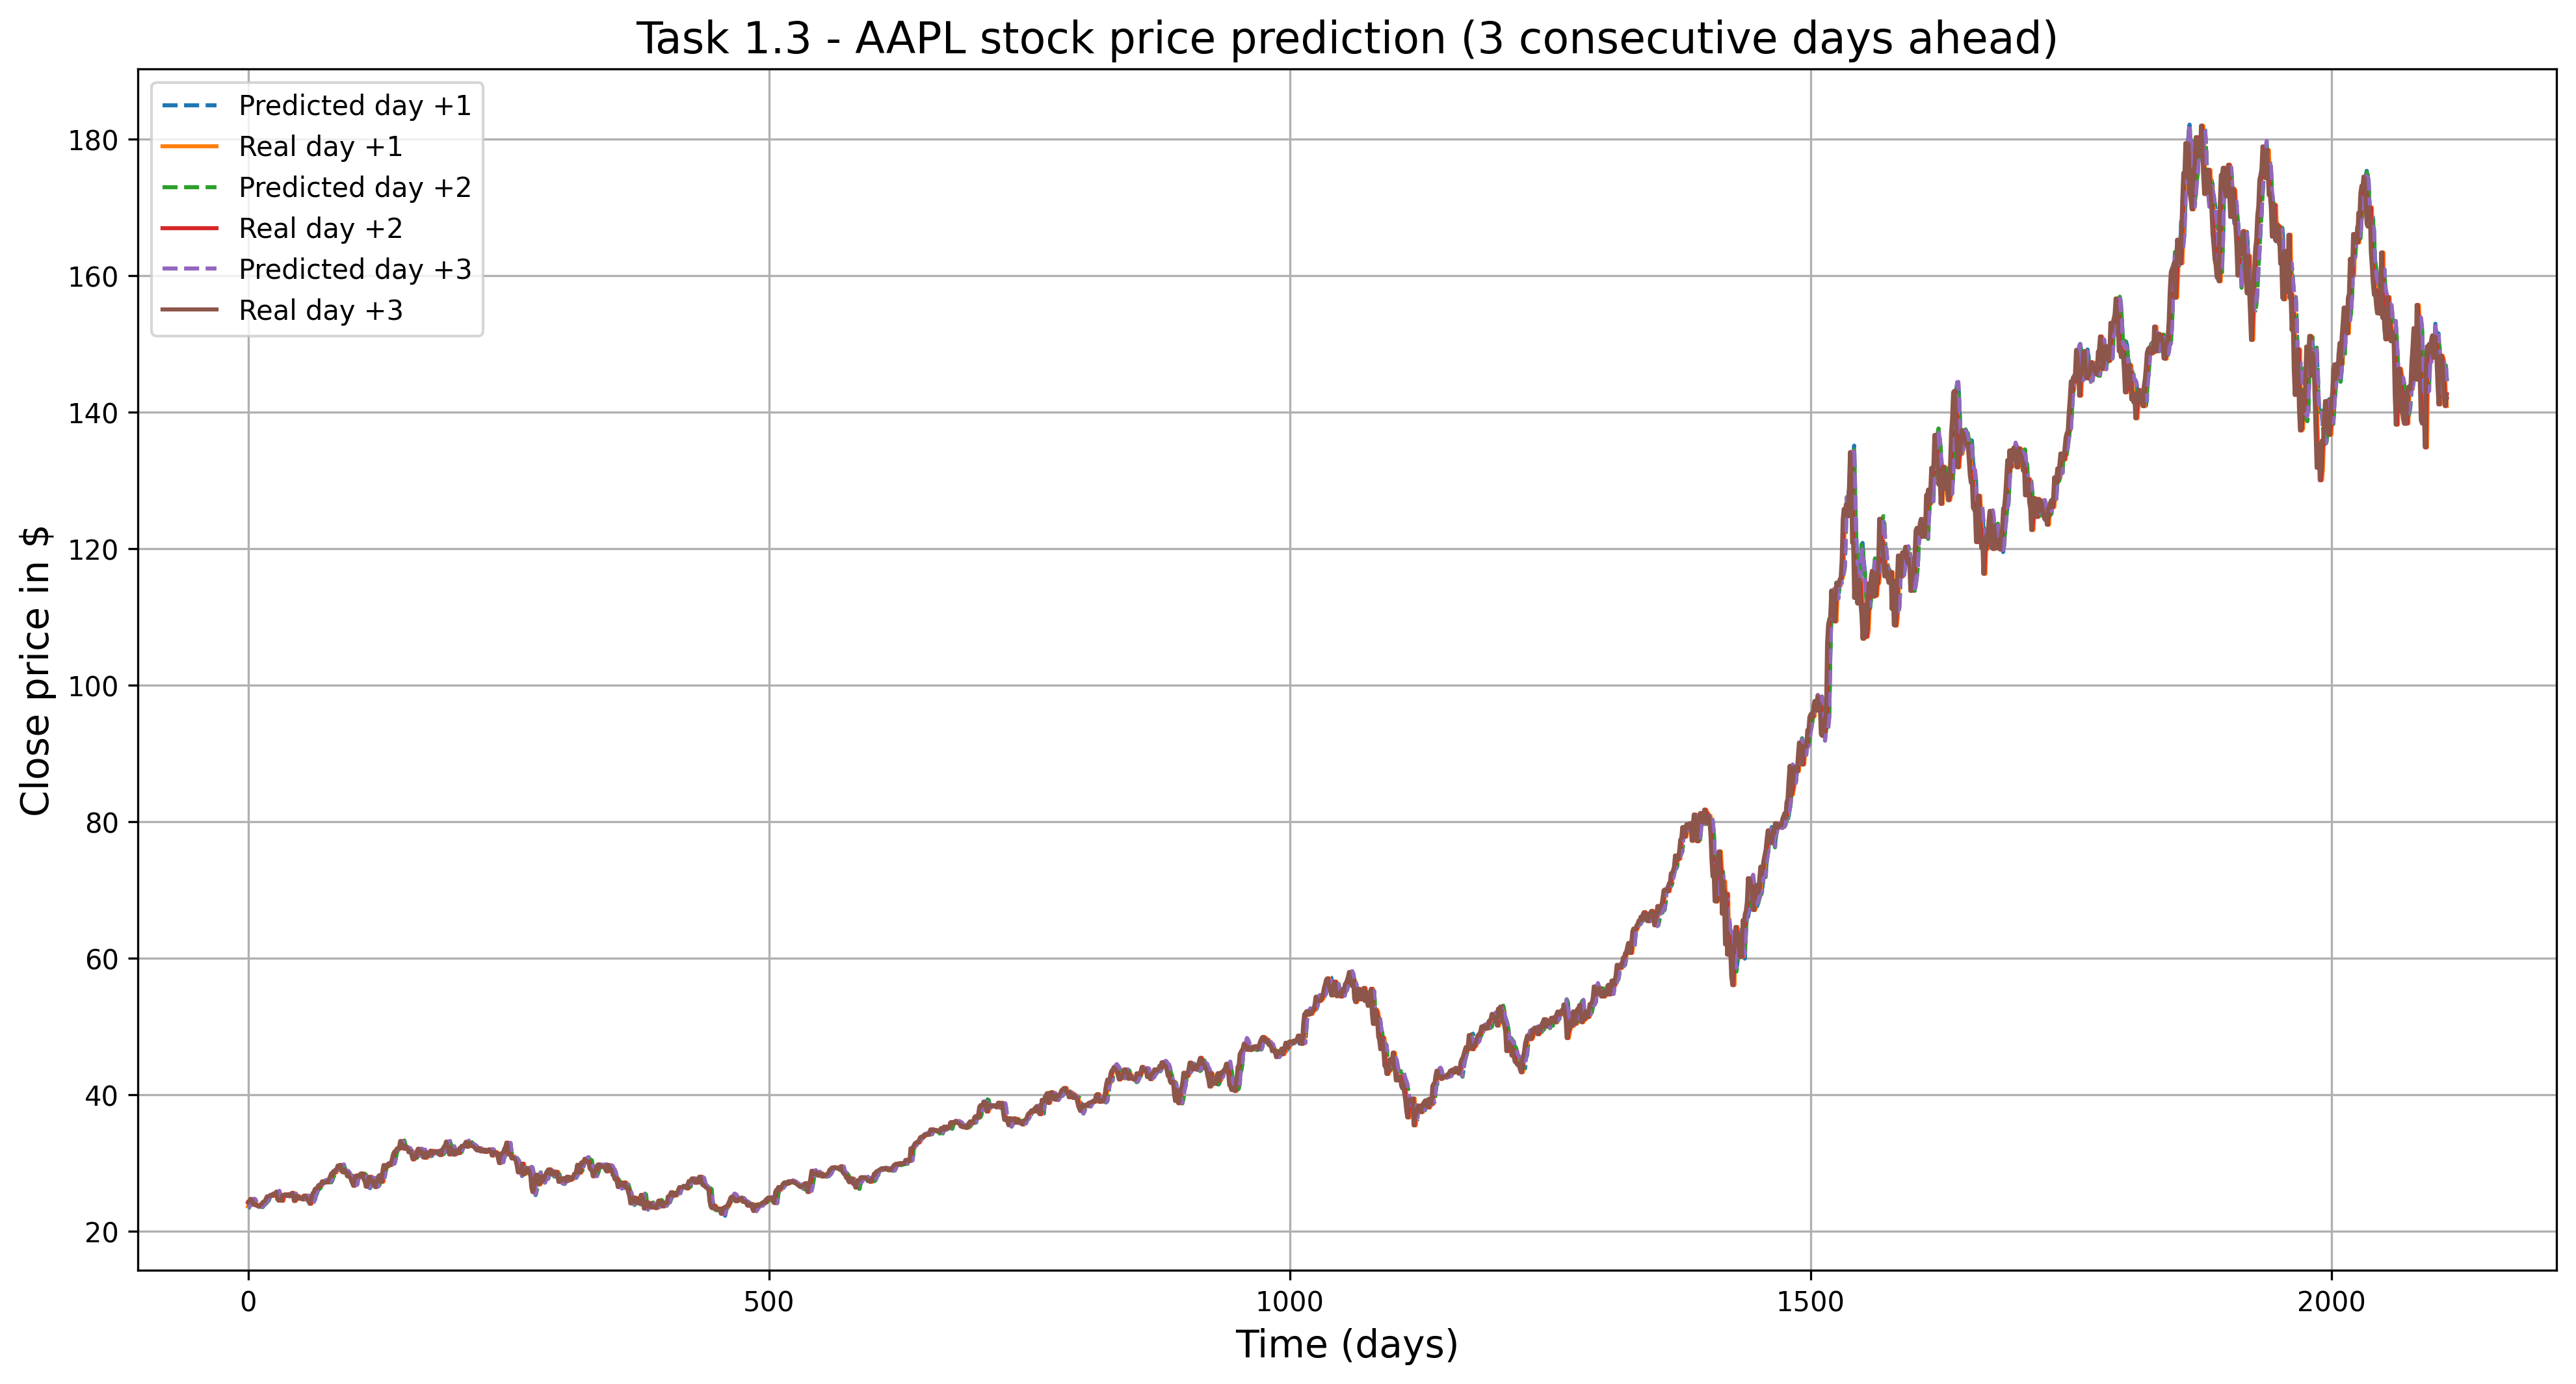

In [ ]:
# De-normalize and plot all K predicted days vs real
y_pred_denorm_13 = per_window_denormalize(y_pred_norm_13, X_test)
y_test_denorm_13 = per_window_denormalize(y_test_norm,    X_test)

plt.figure(figsize=(16, 8), dpi=300)
for k in range(K):
    plt.plot(y_pred_denorm_13[:, k], label=f'Predicted day +{k+1}', linestyle='--')
    plt.plot(y_test_denorm_13[:, k], label=f'Real day +{k+1}')

plt.title(f'Task 1.3 - AAPL stock price prediction ({K} consecutive days ahead)', fontsize=16)
plt.xlabel('Time (days)', fontsize=14)
plt.ylabel('Close price in $', fontsize=14)
plt.grid()
plt.legend()
plt.show()

# Task 1 Comparison

Comparing MSE and RMSE across the three task variants. We expect prediction difficulty to increase as the prediction horizon gets further from the input window.

In [ ]:
results = pd.DataFrame({
    'Task':       ['1.1 - Next day',     f'1.2 - {N}th day ahead', f'1.3 - {K} days ahead'],
    'MSE (norm)': [mse_11,                mse_12,                   mse_13],
    'RMSE (norm)':[rmse_11_norm,          rmse_12_norm,             rmse_13_norm],
})
print(results.to_string(index=False))

# Score each day separately to see which days are easy vs hard
for k in range(K):
    mse_day_k = mean_squared_error(y_pred_norm_13[:, k], y_test_norm[:, k])
    print(f"Day +{k+1} MSE: {mse_day_k:.4f}")

               Task  MSE (norm)  RMSE (norm)
     1.1 - Next day    0.016347     0.127857
1.2 - 3th day ahead    0.100538     0.317077
 1.3 - 3 days ahead    0.024462     0.156405
Day +1 MSE: 0.0142
Day +2 MSE: 0.0248
Day +3 MSE: 0.0344


**Observations:**

- Task 1.1 establishes the baseline using the demo's architecture extended to 6 features
- Task 1.2 typically shows a slightly higher error than 1.1 since predicting further into the future is harder
- Task 1.3 predicts multiple days at once, so the error is averaged across K outputs

The general trend is that prediction error grows with prediction horizon, which matches financial intuition — short-term price movements are more predictable than longer-term ones.

**Notes on methodology:**

- Single-stock approach (AAPL) chosen because it has the longest continuous trading history in the dataset, satisfying the assignment's "120+ historical data points" requirement comfortably
- 30-day window matches the demo and represents roughly one trading month of context
- Per-window normalization handles the wide price range across decades by squeezing each window to 0-1 independently
- Volume normalized separately from prices since it is on a completely different magnitude (millions vs hundreds)
- Train/Val/Test split respects chronological order with `shuffle=False`